In [1]:
import os
os.chdir("../scripts")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import math
from analysis_tools_cython import *
from glob import glob

In [2]:
import lightkurve as lk

In [3]:
results = lk.search_lightcurve('TIC 229790952',author='QLP')

In [4]:
sectors = [int(mission.split(' ')[-1]) for mission in results.mission]
sectors

[14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 40,
 41,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 73,
 74,
 75,
 76,
 79,
 80,
 81]

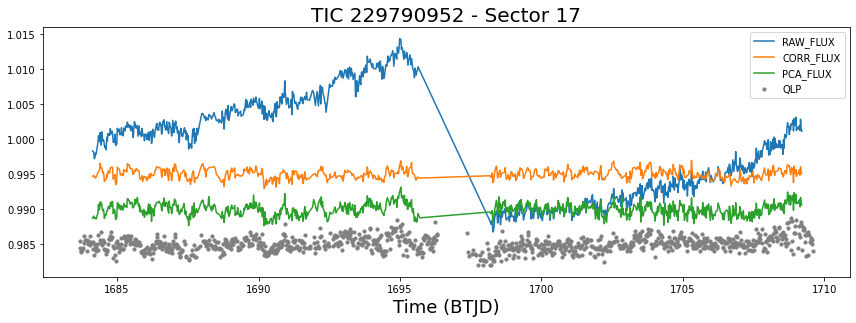

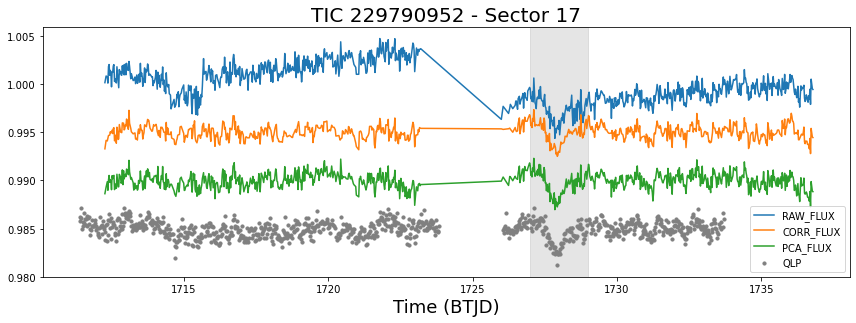

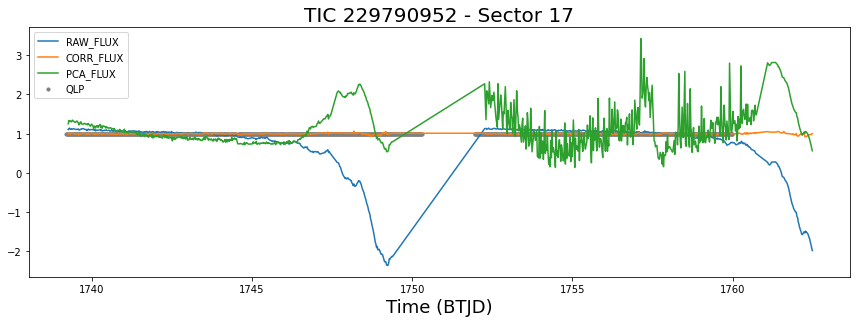

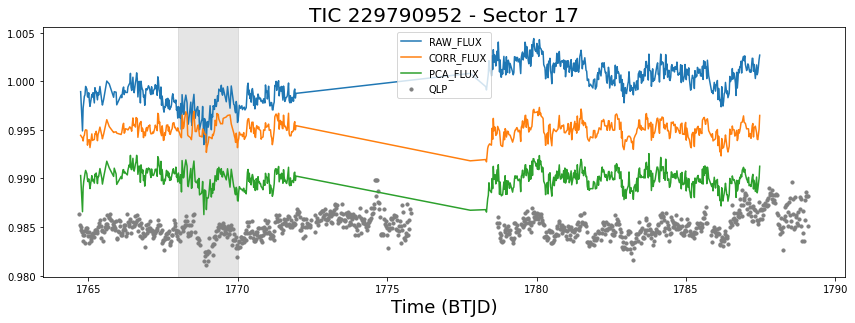

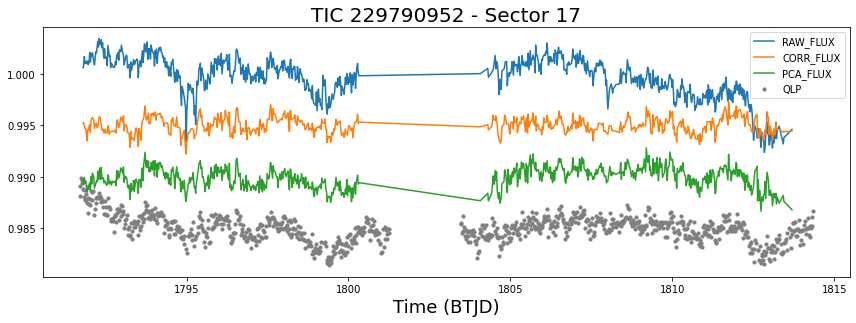

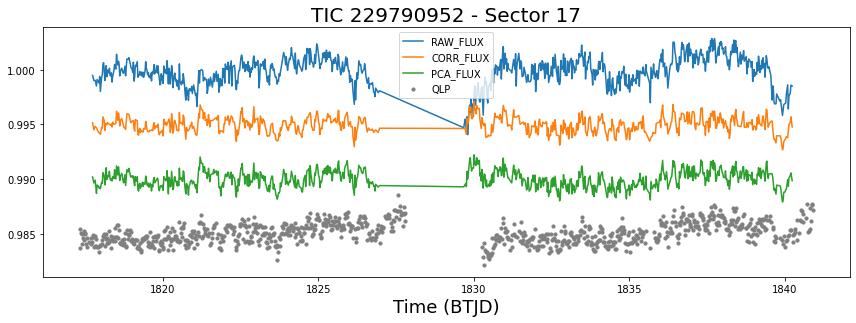

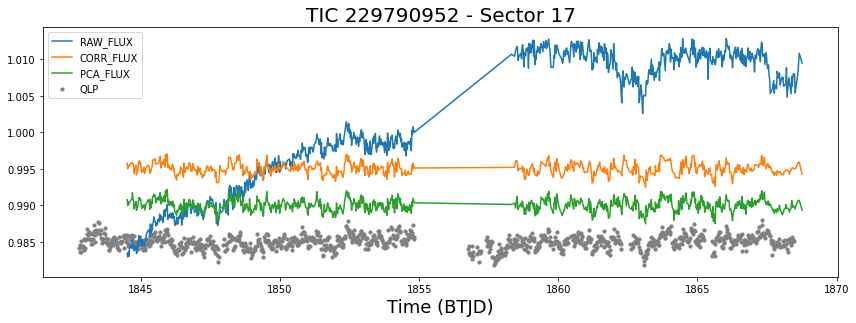

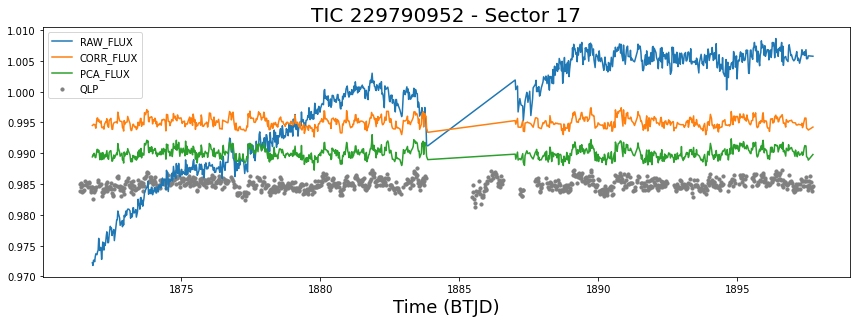

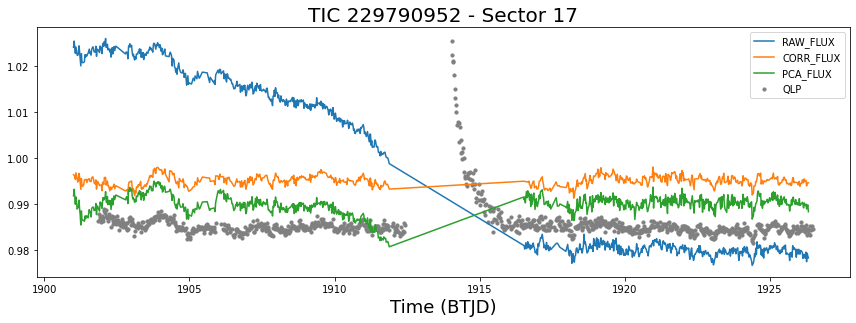

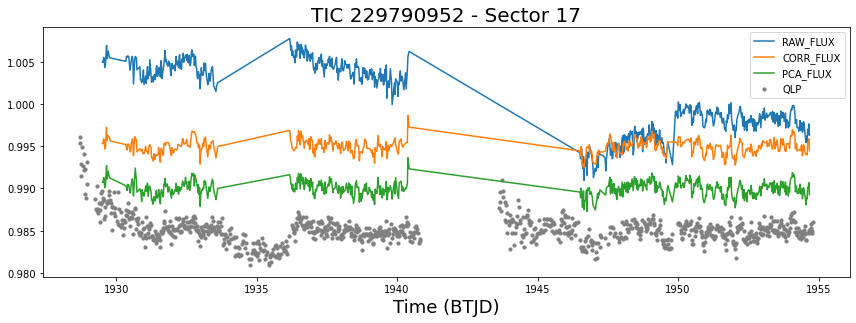

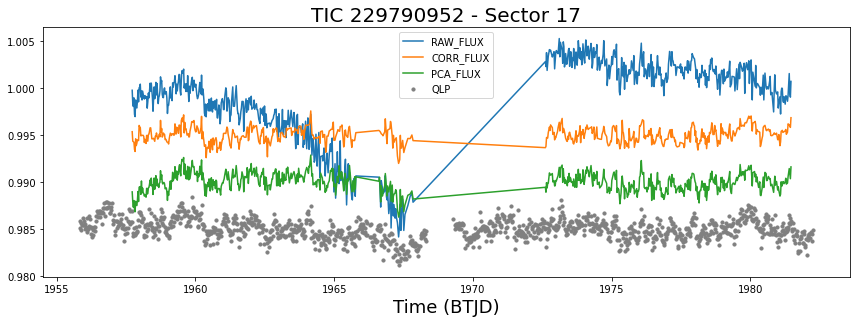

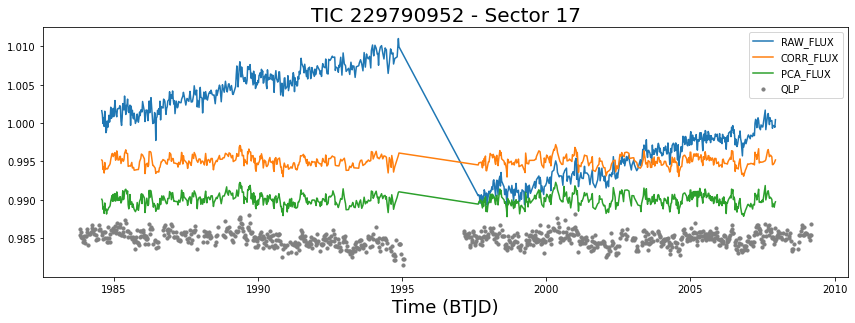

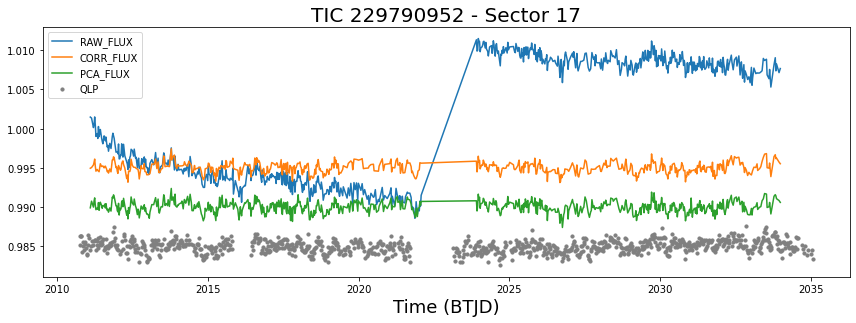

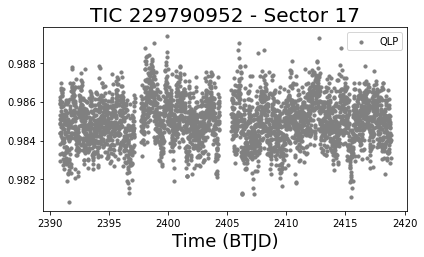

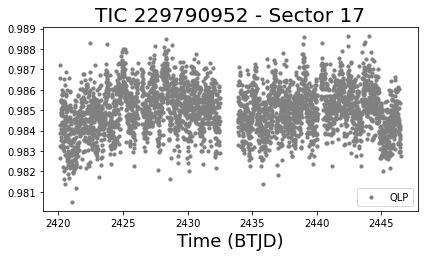

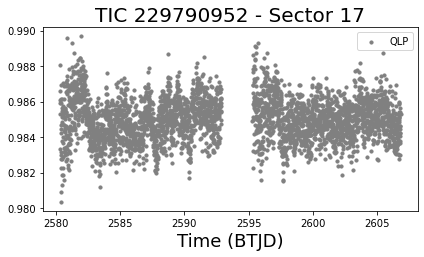

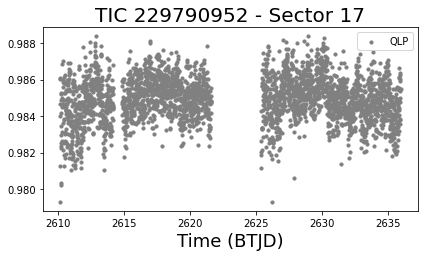

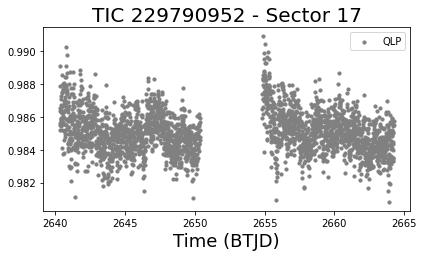

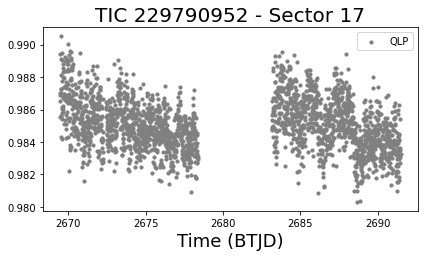

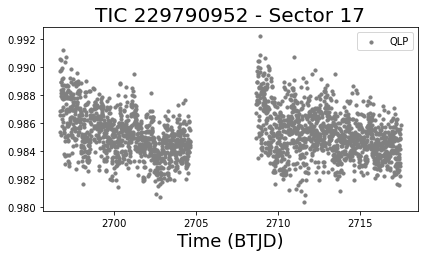

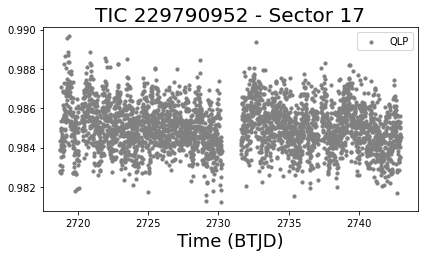

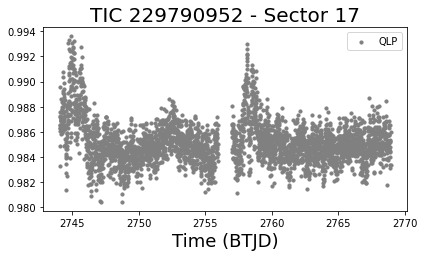

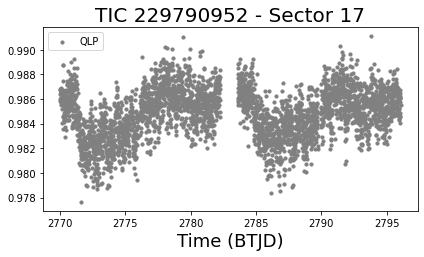

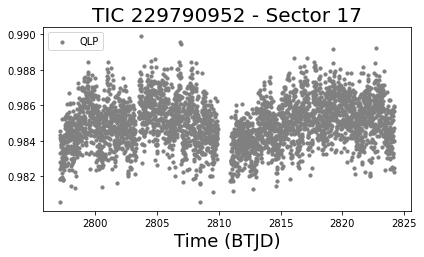

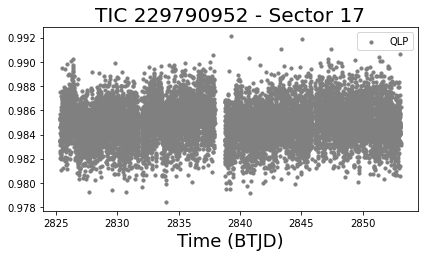

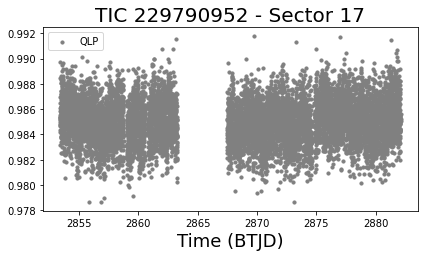

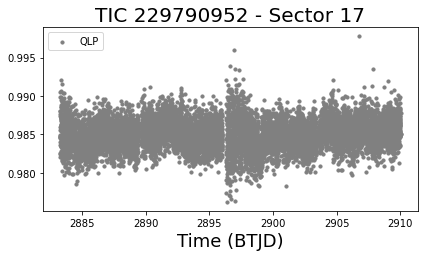

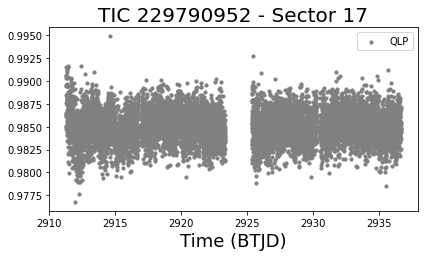

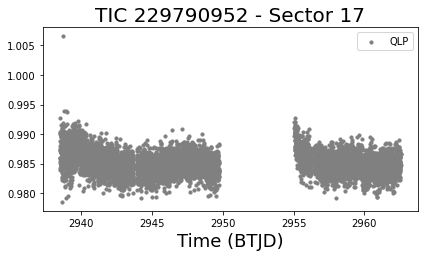

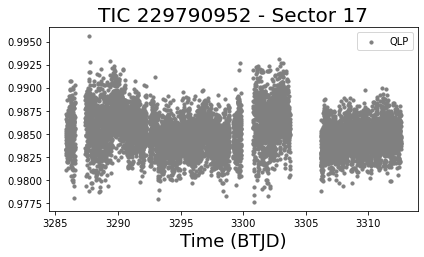

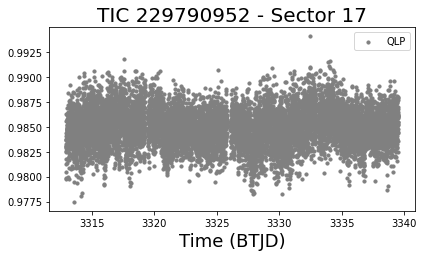

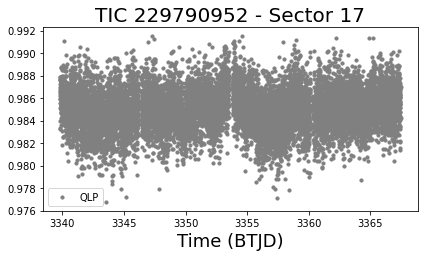

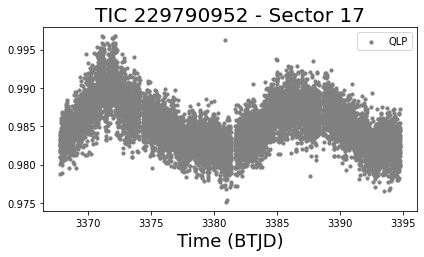

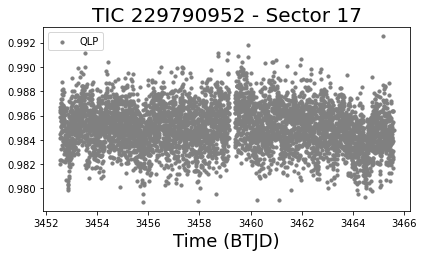

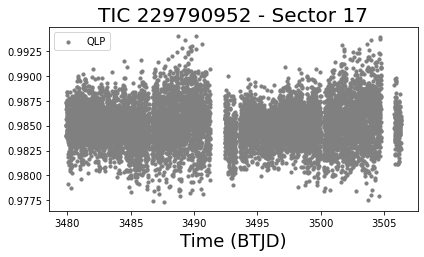

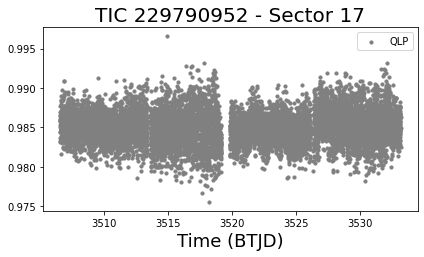

In [5]:
for i in sectors:
    #fig, axs = plt.subplots(1, 1, figsize=(20, 5))
    
    if i <= 26:
        path = f'/storage/astro2/phrdhx/eleanor-lite-project-v2/s00{i}/hlsp_gsfc-eleanor-lite_tess_ffi_s00{i}-0000000229790952_tess_v1.0_lc.fits'
        lc, info = import_lightcurve(path)
    
    qlplc = lk.search_lightcurve('TIC 229790952',sector=i,author='QLP').download()
    qlplc = qlplc[qlplc.quality.value == 0]
    
    # First subplot - Light curves
    if i <= 26:
        plt.figure(figsize=(12,5))
        plt.plot(lc['TIME'],lc['RAW_FLUX']/np.nanmedian(lc['RAW_FLUX']),label='RAW_FLUX')
        plt.plot(lc['TIME'],lc['CORR_FLUX']/np.nanmedian(lc['CORR_FLUX'])-0.005,label='CORR_FLUX')
        plt.plot(lc['TIME'],lc['PCA_FLUX']/np.nanmedian(lc['PCA_FLUX'])-0.01,label='PCA_FLUX')
    

        # axs[1].plot(lc['TIME'], lc['FLUX_BKG'], 'k-', label='Background Flux')
        # axs[1].set_ylabel('FLUX_BKG')
        # axs[2].plot(lc['TIME'], lc['X_CENTROID'], 'r-', label='X Centroid')
        # axs[2].set_ylabel('X_CENTROID')

        # axs[3].plot(lc['TIME'], lc['Y_CENTROID'], 'b-', label='Y Centroid')
        # axs[3].set_ylabel('Y_CENTROID')
    plt.scatter(qlplc.time.value,qlplc.flux.value/np.nanmedian(qlplc.flux.value)-0.015,label='QLP',color='gray',s=10)
    
    # Add gray shaded regions to all subplots
    #for ax in axs:
    if (lc['TIME'].min() <= 1725) and (lc['TIME'].max() >= 1715):
        plt.axvspan(1727, 1729, color='gray', alpha=0.2)
    if (lc['TIME'].min() <= 1766) and (lc['TIME'].max() >= 1780):
        plt.axvspan(1768, 1770, color='gray', alpha=0.2)
    #    ax.set_xlabel('BTJD')
        
    
    # Set title for the entire figure
    plt.title(f'TIC 229790952 - Sector 17', fontsize=20)
    plt.xlabel('Time (BTJD)',fontsize=18)
    # Add legend to first subplot
    plt.legend()
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save and show
    plt.savefig(f'tic229790952_s{i}_extended.png',dpi=300,bbox_inches='tight')
    plt.show()

In [8]:
path = '/storage/astro2/phrdhx/eleanor-lite-project-v2/s0015/hlsp_gsfc-eleanor-lite_tess_ffi_s0015-0000000229790952_tess_v1.0_lc.fits'

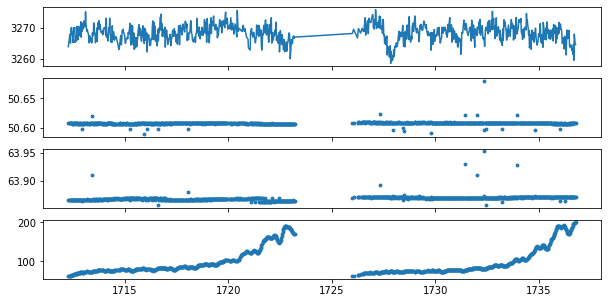

In [24]:
lc, info = import_lightcurve(path)
fig2, ax2 = plt.subplots(4,1,figsize=(10,5),sharex=True)
ax2[0].plot(lc['TIME'],lc['PCA_FLUX'])
ax2[1].scatter(lc['TIME'].value,lc['X_CENTROID'],s=8)
ax2[2].scatter(lc['TIME'].value,lc['Y_CENTROID'],s=8)
ax2[3].scatter(lc['TIME'].value,lc['FLUX_BKG'],s=8)

In [26]:
import lightkurve as lk

array([47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])

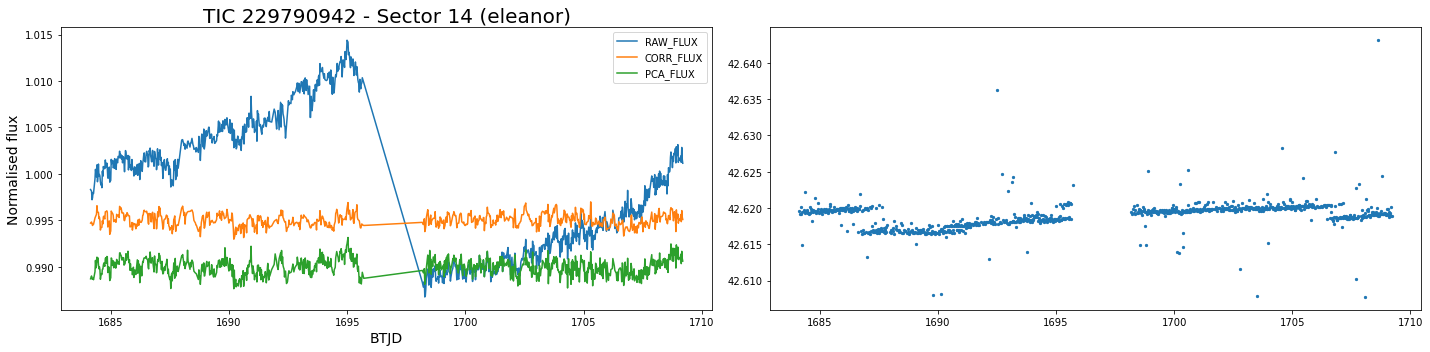

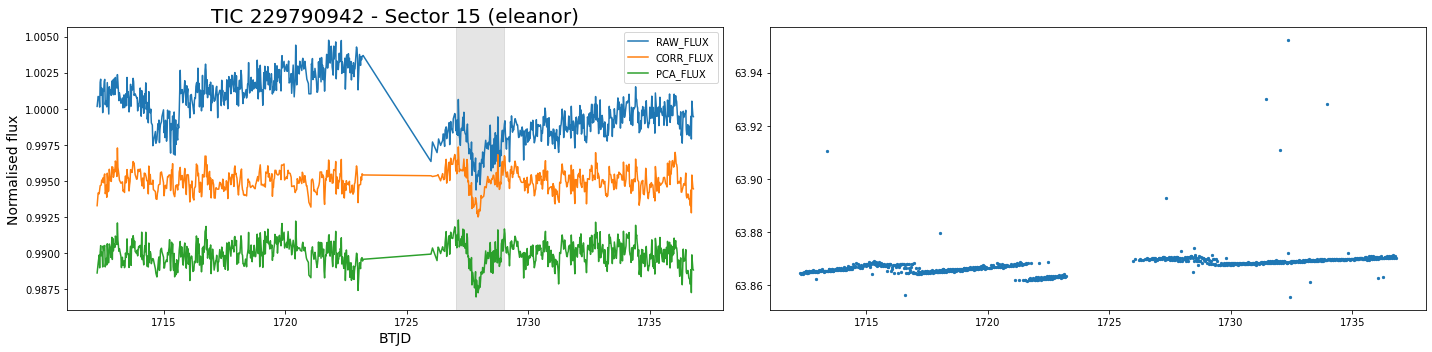

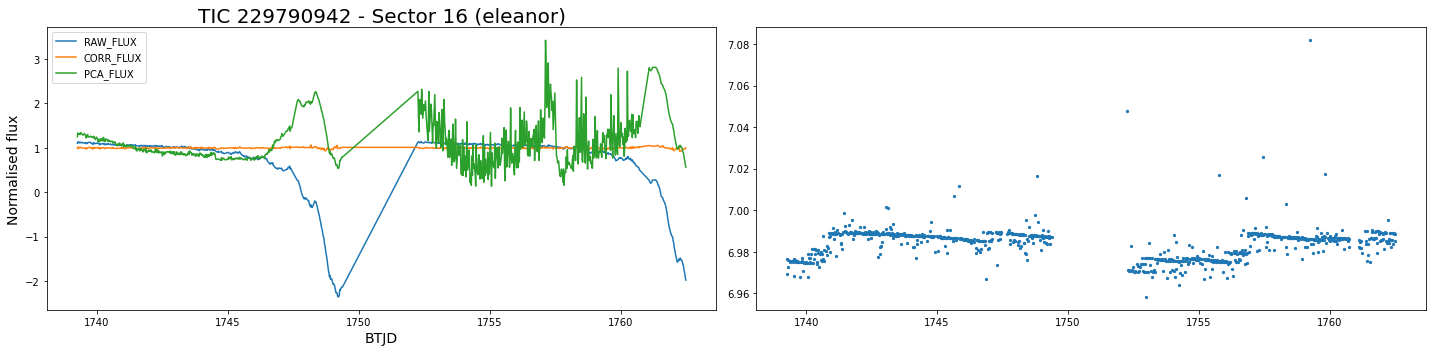

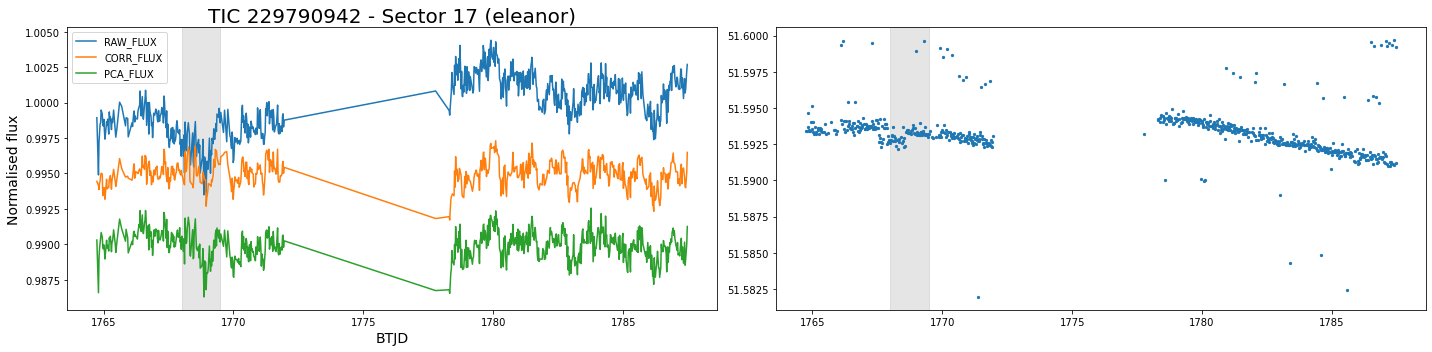

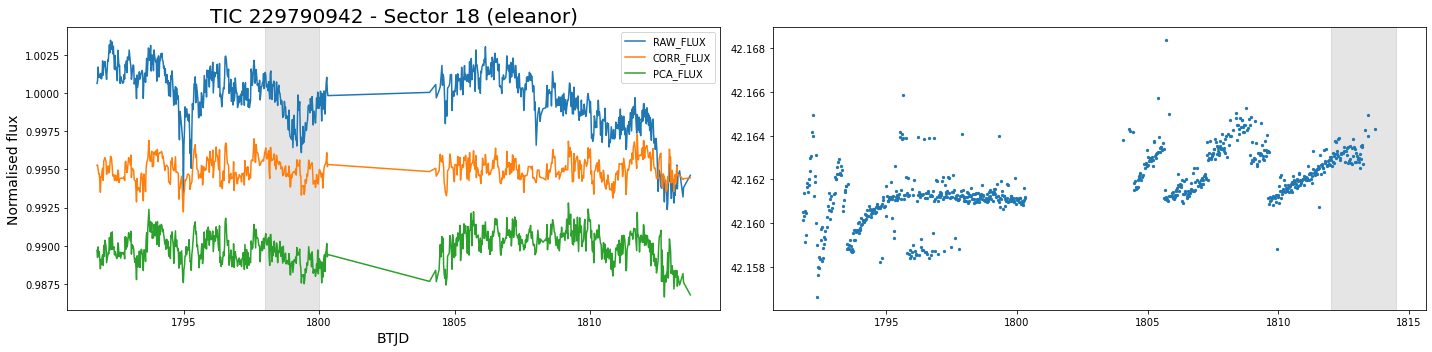

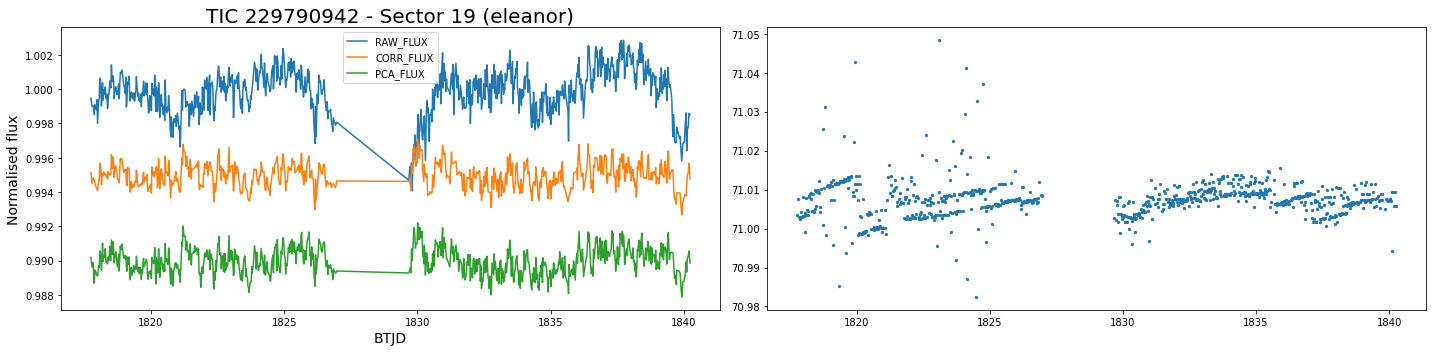

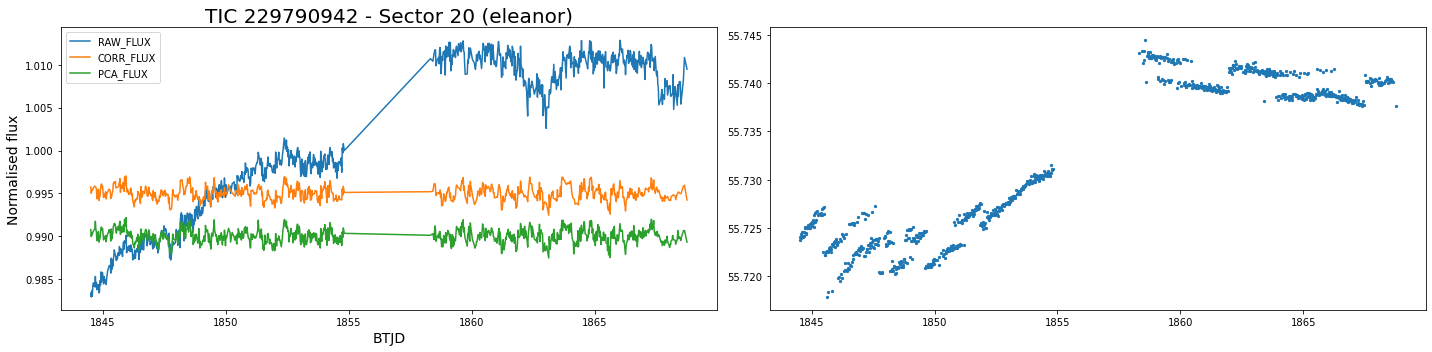

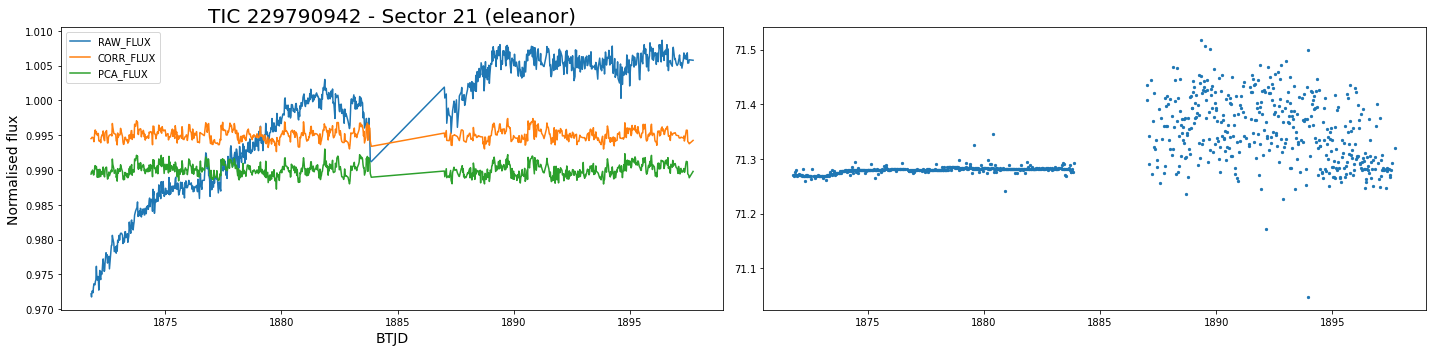

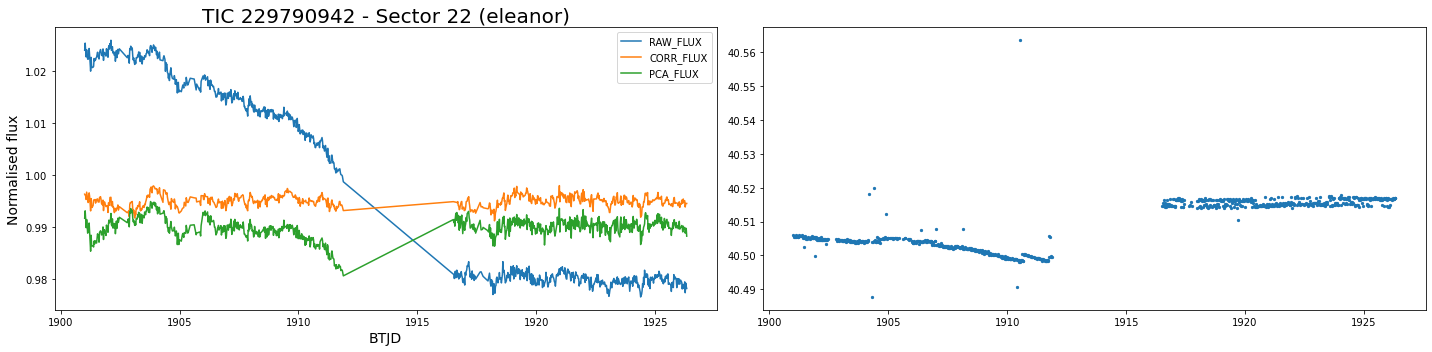

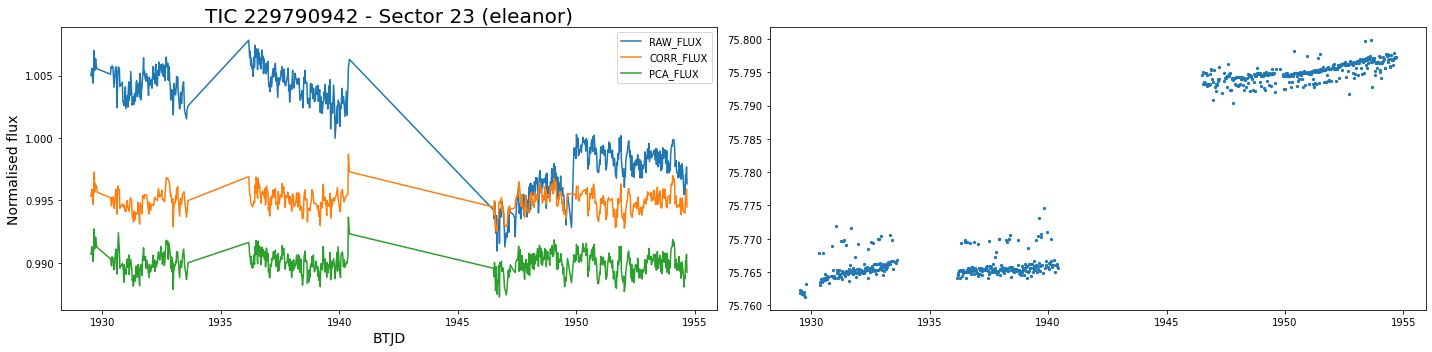

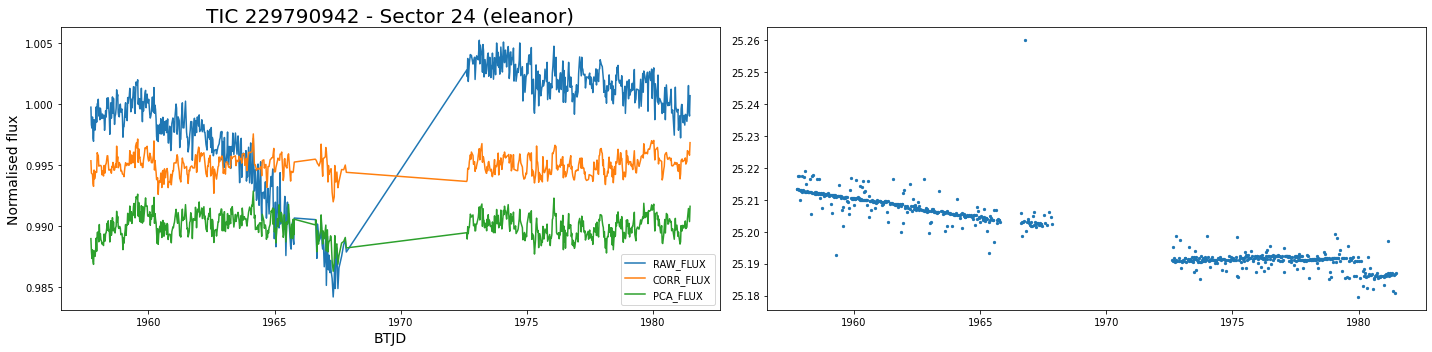

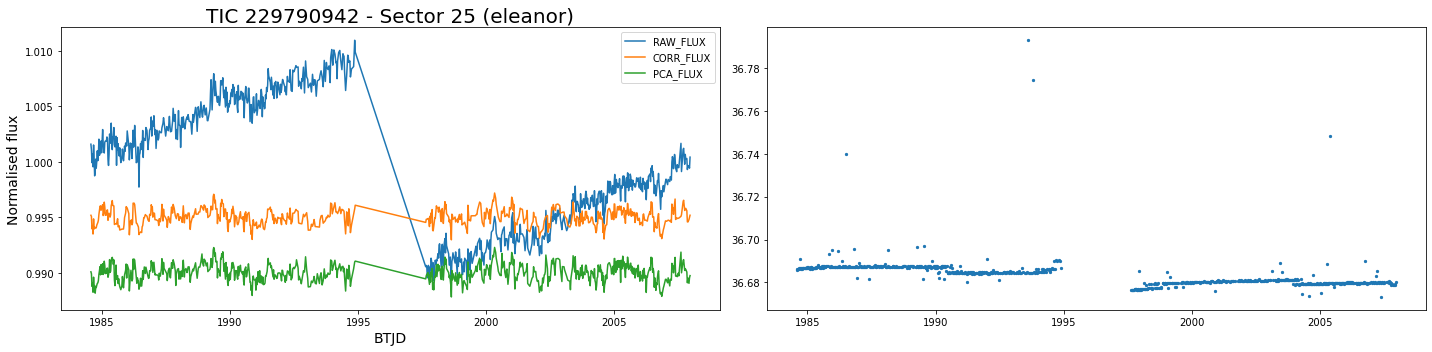

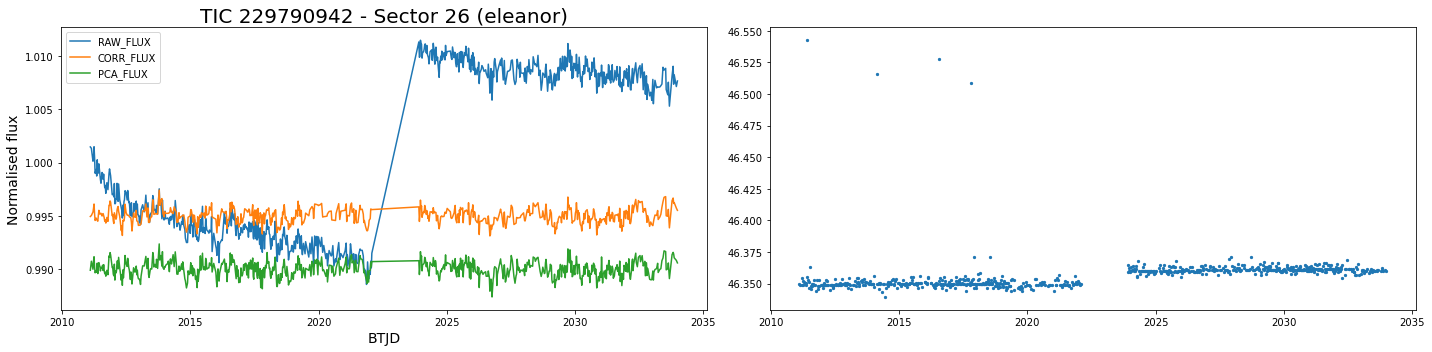

In [70]:
for i in sectors:
    path = f'/storage/astro2/phrdhx/eleanor-lite-project-v2/s00{i}/hlsp_gsfc-eleanor-lite_tess_ffi_s00{i}-0000000229790952_tess_v1.0_lc.fits'
    lc, info = import_lightcurve(path)
    
    # Create a figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,5))
    
    # First subplot - your current plot
    ax1.plot(lc['TIME'],lc['RAW_FLUX']/np.nanmedian(lc['RAW_FLUX']),label='RAW_FLUX')
    ax1.plot(lc['TIME'],lc['CORR_FLUX']/np.nanmedian(lc['CORR_FLUX'])-0.005,label='CORR_FLUX')
    ax1.plot(lc['TIME'],lc['PCA_FLUX']/np.nanmedian(lc['PCA_FLUX'])-0.01,label='PCA_FLUX')
    
    # Check if time ranges include values for shading
    if (lc['TIME'].min() <= 1725) and (lc['TIME'].max() >= 1715):
        ax1.axvspan(1727, 1729, color='gray', alpha=0.2)
    if (lc['TIME'].min() <= 1768) and (lc['TIME'].max() >= 1780):
        ax1.axvspan(1768, 1769.5, color='gray', alpha=0.2)
        ax2.axvspan(1768, 1769.5, color='gray', alpha=0.2)

    if (lc['TIME'].min() <= 1793) and (lc['TIME'].max() >= 1813):
        ax1.axvspan(1798, 1800, color='gray', alpha=0.2)
        ax2.axvspan(1812, 1814.5, color='gray', alpha=0.2)
    
    ax1.set_title(f'TIC 229790942 - Sector {i} (eleanor)',fontsize=20)
    ax1.set_xlabel('BTJD',fontsize=14)
    ax1.set_ylabel('Normalised flux',fontsize=14)
    ax1.legend()


    ax2.scatter(lc['TIME'],lc['Y_CENTROID'],s=5)
    
    # # Second subplot - lightkurve search
    # search_result = lk.search_lightcurve(f'TIC 229790952', sector=i,author='QLP')
    # if len(search_result) > 0:
    #     lk_lc = search_result.download()
    #     lk_lc = lk_lc[lk_lc.quality.value == 0]
    #     lk_lc.plot(ax=ax2)
    #     ax2.set_title(f'TIC 229790942 - Sector {i} (QLP)',fontsize=20)
    #     if (lk_lc.time.value.min() <= 1725) and (lk_lc.time.value.max() >= 1715):
    #         ax2.axvspan(1727, 1729, color='gray', alpha=0.2)

    #ax1.axvspan(1768, 1770, color='gray', alpha=0.2)
    
    plt.tight_layout()
    plt.show()

In [63]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('lightcurves_comparison.pdf') as pdf:
    # Calculate number of pages needed
    num_sectors = len(sectors)
    num_pages = (num_sectors + 2) // 3  # This rounds up to ensure all sectors fit
    
    for page in range(num_pages):
        # Create one figure per page with 3 rows and 2 columns
        fig, axes = plt.subplots(3, 2, figsize=(20, 15))
        
        for row in range(3):
            sector_idx = page * 3 + row
            if sector_idx >= len(sectors):  # Skip if we've run out of sectors
                break
                
            i = sectors[sector_idx]
            path = f'/storage/astro2/phrdhx/eleanor-lite-project-v2/s00{i}/hlsp_gsfc-eleanor-lite_tess_ffi_s00{i}-0000000229790952_tess_v1.0_lc.fits'
            lc, info = import_lightcurve(path)
            
            # Plot eleanor data
            axes[row, 0].plot(lc['TIME'], lc['RAW_FLUX']/np.nanmedian(lc['RAW_FLUX']), label='RAW_FLUX')
            axes[row, 0].plot(lc['TIME'], lc['CORR_FLUX']/np.nanmedian(lc['CORR_FLUX'])-0.005, label='CORR_FLUX')
            axes[row, 0].plot(lc['TIME'], lc['PCA_FLUX']/np.nanmedian(lc['PCA_FLUX'])-0.01, label='PCA_FLUX')
            
            # Add shading conditions
            if (lc['TIME'].min() <= 1725) and (lc['TIME'].max() >= 1715):
                axes[row, 0].axvspan(1727, 1729, color='gray', alpha=0.2)
            if (lc['TIME'].min() <= 1768) and (lc['TIME'].max() >= 1780):
                axes[row, 0].axvspan(1768, 1769.5, color='gray', alpha=0.2)
                axes[row, 1].axvspan(1768, 1769.5, color='gray', alpha=0.2)
            if (lc['TIME'].min() <= 1793) and (lc['TIME'].max() >= 1813):
                axes[row, 0].axvspan(1798, 1800, color='gray', alpha=0.2)
                axes[row, 1].axvspan(1812, 1814.5, color='gray', alpha=0.2)
            
            axes[row, 0].set_title(f'TIC 229790952 - Sector {i} (eleanor)', fontsize=16)
            axes[row, 0].set_xlabel('BTJD', fontsize=12)
            axes[row, 0].set_ylabel('Normalised flux', fontsize=12)
            axes[row, 0].legend()
            
            # Plot QLP data
            search_result = lk.search_lightcurve(f'TIC 229790952', sector=i, author='QLP')
            if len(search_result) > 0:
                lk_lc = search_result.download()
                lk_lc = lk_lc[lk_lc.quality.value == 0]
                lk_lc.plot(ax=axes[row, 1])
                axes[row, 1].set_title(f'TIC 229790952 - Sector {i} (QLP)', fontsize=16)
                if (lk_lc.time.value.min() <= 1725) and (lk_lc.time.value.max() >= 1715):
                    axes[row, 1].axvspan(1727, 1729, color='gray', alpha=0.2)
            
            # Make y-axes same for each row
            axes[row, 0].sharey(axes[row, 1])
        
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()

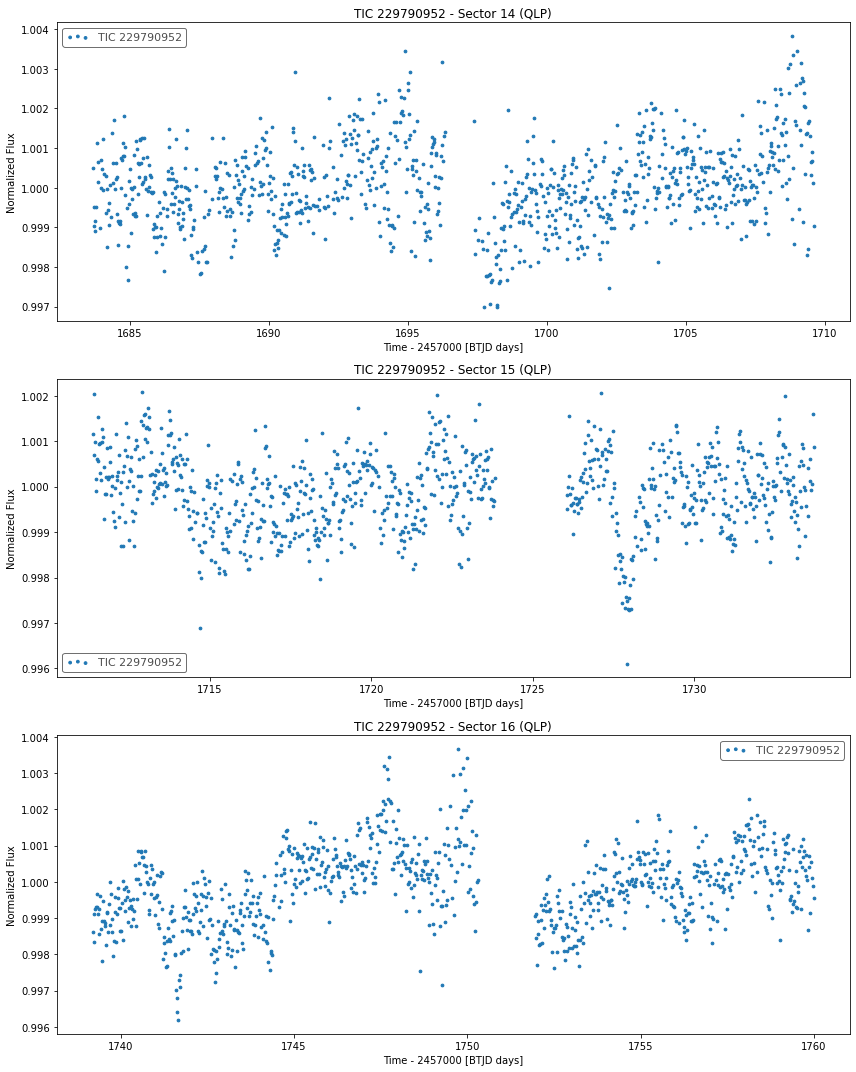

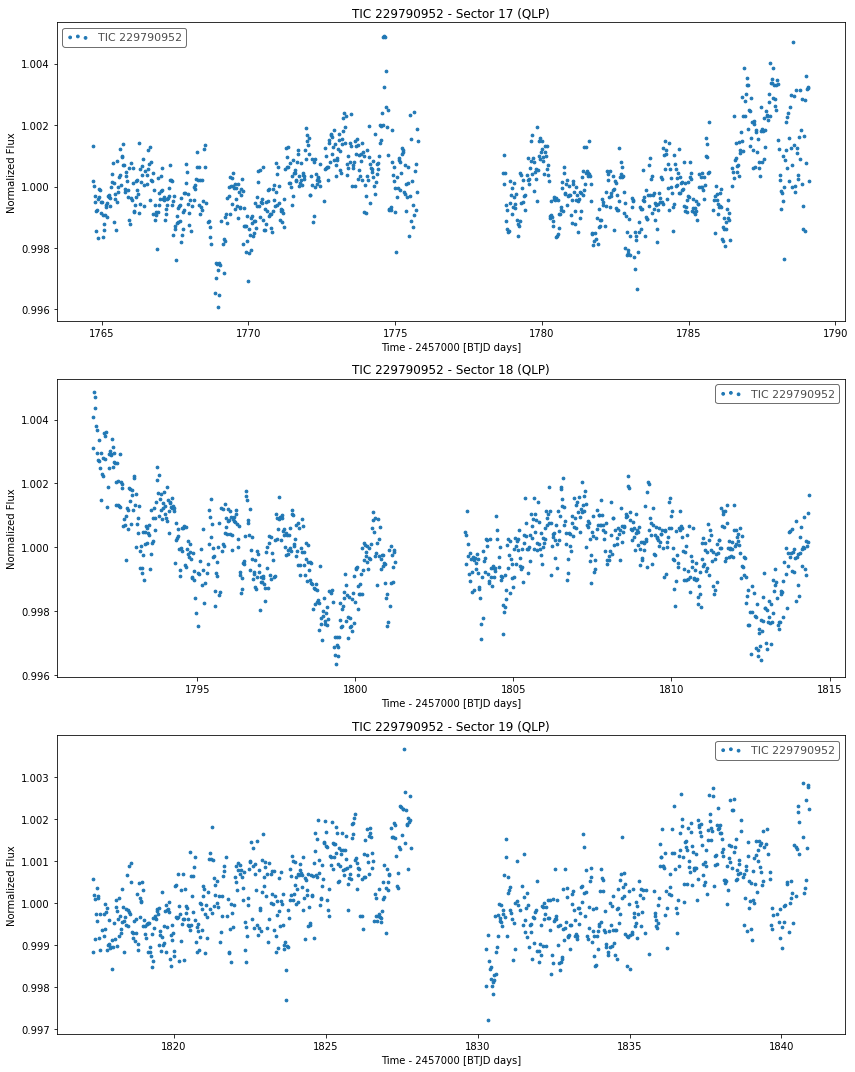

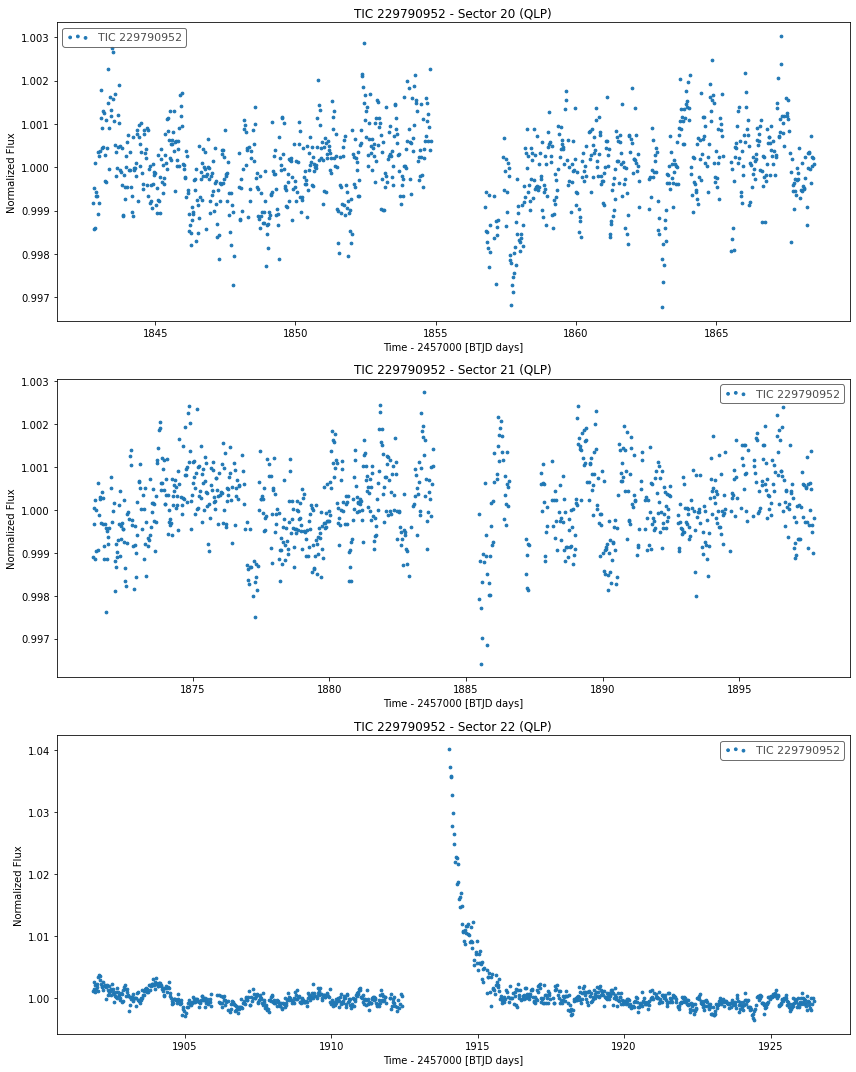

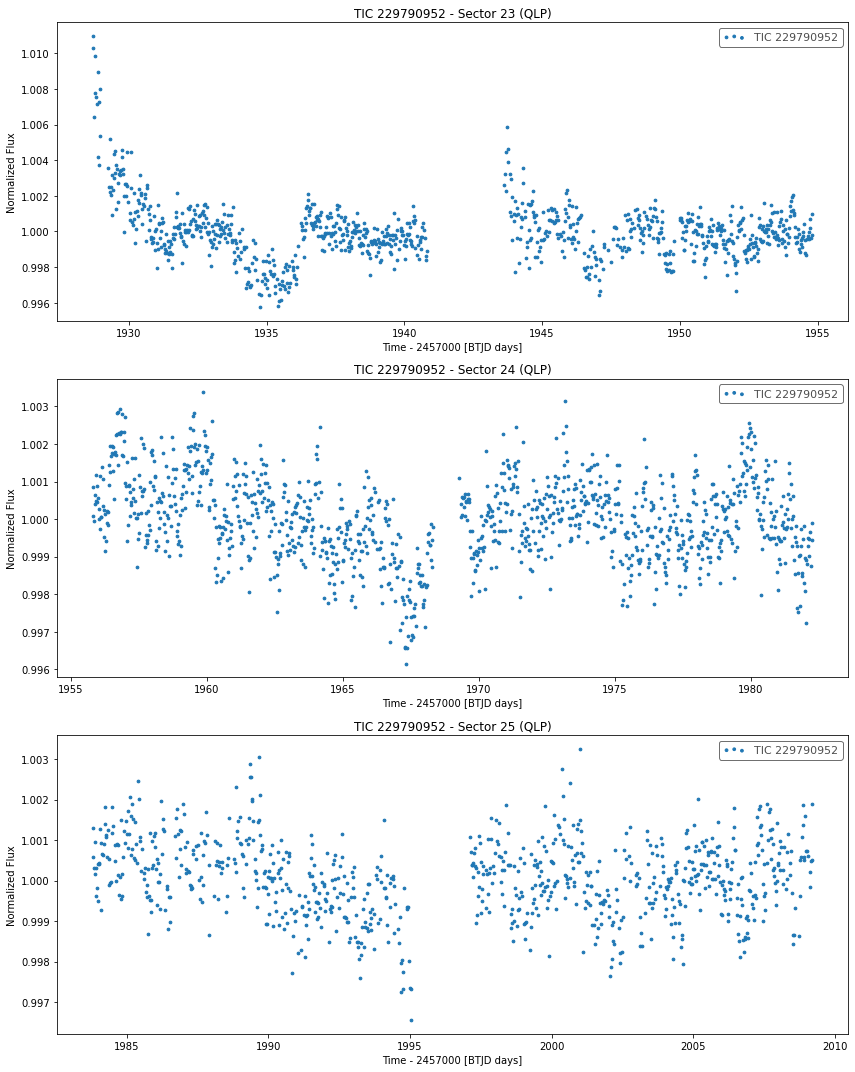

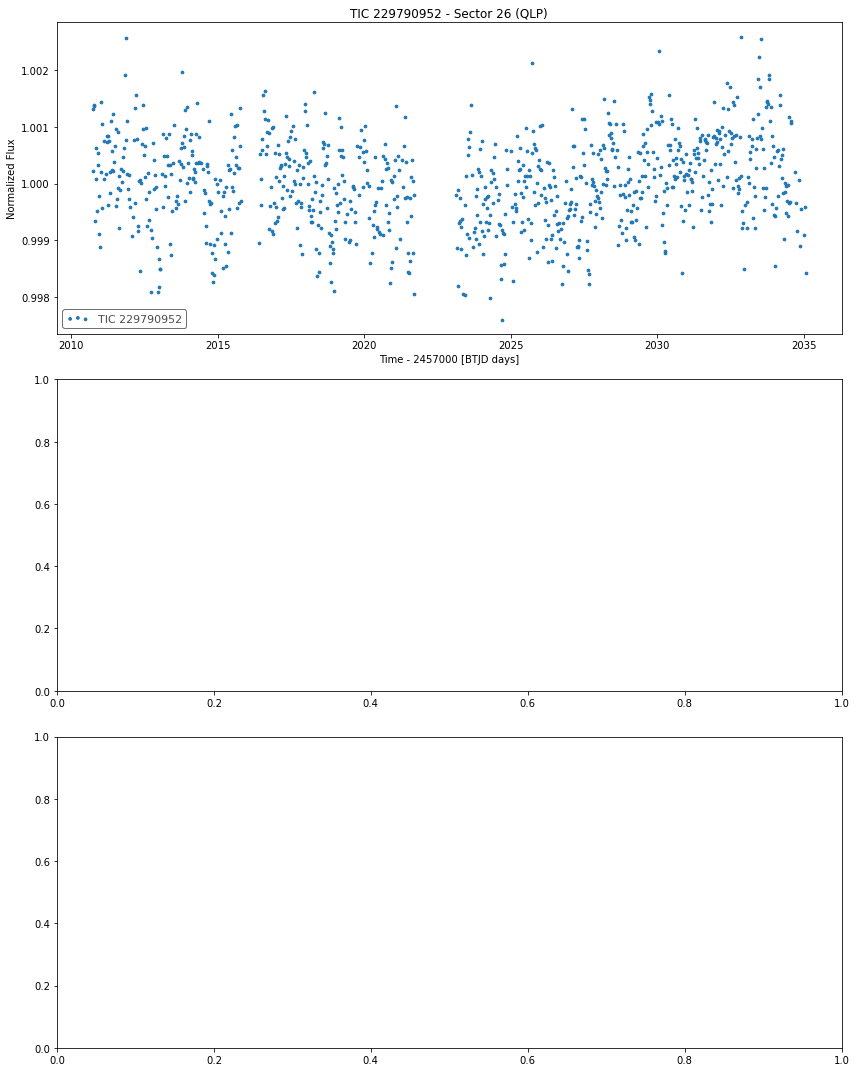

In [80]:
sectors = np.arange(14,27,1)
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('qlp_lightcurves_2.pdf') as pdf:
    # Calculate number of pages needed
    num_sectors = len(sectors)
    num_pages = (num_sectors + 2) // 3  # Rounds up to ensure all sectors fit
    
    for page in range(num_pages):
        # Create one figure per page with 3 subplots
        fig, axes = plt.subplots(3, 1, figsize=(12, 15))
        
        for row in range(3):
            sector_idx = page * 3 + row
            if sector_idx >= len(sectors):  # Skip if we've run out of sectors
                break
                
            i = sectors[sector_idx]
            lc = lk.search_lightcurve('TIC 229790952', author='QLP', sector=i).download()
            lc = lc[lc.quality.value == 0]
            lc.scatter(ax=axes[row],s=30)
            axes[row].set_title(f'TIC 229790952 - Sector {i} (QLP)')
        
        plt.tight_layout()
        pdf.savefig(fig)
        plt.show()